# **Comparación de resultados: scikit-learn vs PySpark**

En esta sección se comparan los resultados obtenidos con los flujos de modelado implementados en scikit-learn y PySpark.

La comparación considera tanto el desempeño predictivo como el costo computacional, con el fin de evaluar las ventajas y limitaciones de cada enfoque sobre el dataset completo de Lending Club.

## **Tabla comparativa de métricas**

In [1]:
import pandas as pd

comparison_metrics = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "scikit-learn": [0.881205, 0.000000, 0.000000, 0.000000, 0.695485],
    "PySpark": [None, 0.775518, None, 0.824741, 0.686732]
})

comparison_metrics

,Métrica,scikit-learn,PySpark
0,Accuracy,0.881205,NaN
1,Precision,0.000000,0.775518
2,Recall,0.000000,NaN
3,F1-score,0.000000,0.824741
4,ROC AUC,0.695485,0.686732


La comparación de métricas muestra que ambos enfoques alcanzaron valores de ROC AUC relativamente cercanos, lo cual sugiere una capacidad de discriminación moderada en ambos casos.

Sin embargo, en scikit-learn se observó explícitamente que el modelo no predijo ningún caso positivo bajo el umbral por defecto, mientras que en PySpark las métricas ponderadas reflejan un desempeño global razonable, aunque también condicionado por el desbalance de clases.

## **Tabla comparativa de tiempos de cómputo**

In [2]:
comparison_times = pd.DataFrame({
    "Etapa": ["Preprocesamiento", "Entrenamiento con validación", "Predicción"],
    "scikit-learn (s)": [None, 8845.24, 2.68],
    "PySpark (s)": [None, 4996.80, 0.04]
})

comparison_times

,Etapa,scikit-learn (s),PySpark (s)
0,Preprocesamiento,NaN,NaN
1,Entrenamiento con validación,8845.24,4996.80
2,Predicción,2.68,0.04


En términos de tiempo de cómputo, el flujo de PySpark mostró una ventaja importante sobre scikit-learn en la etapa de entrenamiento con validación cruzada, reduciendo de manera notable el tiempo total requerido.

Asimismo, el tiempo de predicción en PySpark fue considerablemente menor. Estos resultados sugieren que, sobre el dataset completo y en el entorno evaluado, PySpark ofrece un flujo más eficiente en términos computacionales para el entrenamiento y la inferencia.

## **Gráfico Comparación de Tiempos**

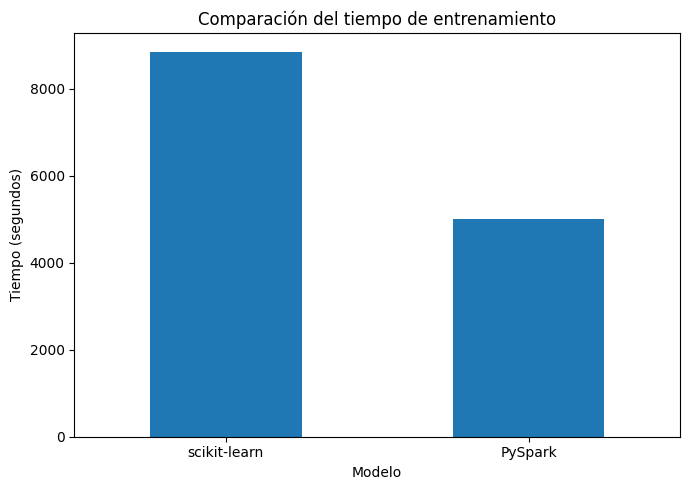

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

train_times = pd.DataFrame({
    "Modelo": ["scikit-learn", "PySpark"],
    "Tiempo (s)": [8845.24, 4996.80]
})

train_times.plot(kind="bar", x="Modelo", y="Tiempo (s)", figsize=(7, 5), legend=False)
plt.title("Comparación del tiempo de entrenamiento")
plt.ylabel("Tiempo (segundos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

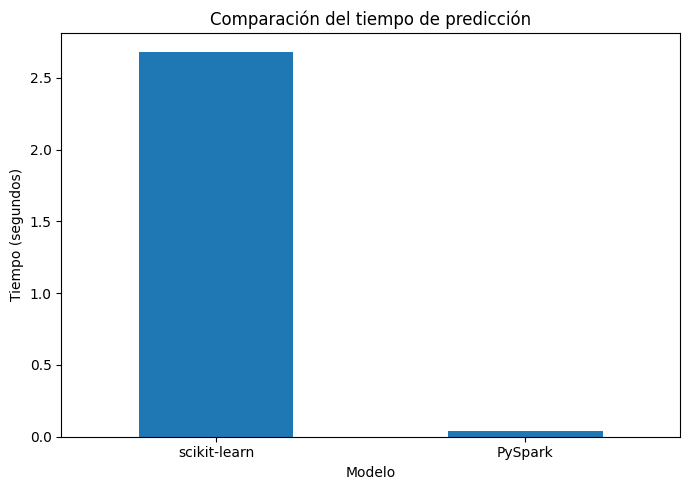

In [8]:
pred_times = pd.DataFrame({
    "Modelo": ["scikit-learn", "PySpark"],
    "Tiempo (s)": [2.68, 0.04]
})

pred_times.plot(kind="bar", x="Modelo", y="Tiempo (s)", figsize=(7, 5), legend=False)
plt.title("Comparación del tiempo de predicción")
plt.ylabel("Tiempo (segundos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Interpretación de los tiempos de cómputo**

La separación entre los tiempos de entrenamiento y predicción permite una comparación más clara entre ambos enfoques, dado que se encuentran en escalas muy diferentes.

En la etapa de entrenamiento, PySpark mostró un tiempo considerablemente menor que scikit-learn, lo cual sugiere una mayor eficiencia computacional al trabajar con el dataset completo.

En la etapa de predicción, ambos modelos fueron rápidos, aunque PySpark volvió a presentar un tiempo inferior. Esto indica que la principal diferencia entre ambos enfoques se observa especialmente en el costo del entrenamiento con validación.

## **Revisión de los resultados**

Con base en los resultados obtenidos, se observa que **PySpark fue más rápido que scikit-learn** en el entrenamiento y en la predicción sobre el dataset completo. En particular, el tiempo total de entrenamiento con validación cruzada se redujo por más del 50% en PySpark, mientras que el tiempo de predicción también resultó inferior. Esta diferencia puede explicarse por varios factores: el trabajo distribuido de Spark, el uso de `cache()` sobre el DataFrame transformado, la configuración explícita de memoria y paralelismo de la sesión Spark, y una mejor adaptación del flujo al procesamiento de grandes volúmenes de datos. En contraste, el flujo de scikit-learn, aunque funcional, resultó mucho más costoso en tiempo dentro de un entorno local al combinar `GridSearchCV`, validación cruzada y codificación one-hot sobre el dataset completo.

En cuanto al desempeño predictivo, **ninguno de los dos modelos fue realmente preciso para identificar la clase minoritaria** bajo la configuración actual. Aunque scikit-learn obtuvo un valor de ROC AUC ligeramente superior al de PySpark, ambos modelos presentaron el mismo problema central: clasificaron todas las observaciones del conjunto de prueba como pertenecientes a la clase mayoritaria (`Fully Paid = 0`). Por tanto, en términos prácticos, ninguno de los dos modelos logró una detección adecuada de los préstamos en default usando el umbral de decisión por defecto. Esto muestra que una métrica global como ROC AUC no es suficiente por sí sola en un problema desbalanceado.

Los resultados de este proyecto sugieren que la ventaja de PySpark empieza a hacerse visible precisamente **cuando se trabaja con un dataset con más del millón de registros**. En conjuntos pequeños o medianos, scikit-learn suele ser más simple y eficiente por su menor sobrecarga. Sin embargo, al escalar hacia volúmenes grandes, el costo computacional de scikit-learn en memoria local crece de forma importante, mientras que PySpark ofrece un flujo más robusto y estable para manejar el procesamiento completo en formato distribuido. Aunque este proyecto no evaluó distintos tamaños intermedios de muestra, la evidencia sugiere que el punto de quiebre aparece cuando el volumen de datos empieza a tensionar claramente la memoria y el tiempo de cómputo en un entorno local.

En relación con la interpretabilidad, **LIME aportó una explicación local útil** para entender por qué el modelo clasificó incorrectamente una instancia específica. Gracias a esta herramienta fue posible identificar qué variables empujaron la predicción hacia la clase ``Fully Paid` y visualizar la contribución local de ciertas características. Esto permitió complementar la evaluación cuantitativa con una interpretación más fina del comportamiento del modelo para comprender que ajustes son necesarios en el dataset para una segunda prueba. No obstante, LIME también presenta limitaciones claras en entornos distribuidos al trabajar en la memoria local, por lo tanto, se integra mejor con scikit-learn que con PySpark. En consecuencia, su utilidad en este proyecto fue mayor para el modelo local que para el flujo distribuido.

Finalmente, las **condiciones obligatorias de la guía tuvieron un efecto importante en el rendimiento**. El uso del dataset completo incrementó notablemente el costo computacional, pero permitió mostrar la diferencia computacional entre ambos modelos. El uso de `CrossValidator` en PySpark y `GridSearchCV` en scikit-learn elevó significativamente los tiempos de entrenamiento, pero permitió una comparación justa entre configuraciones de hiperparámetros.

## **Conclusión**

Aunque PySpark muestra una ventaja clara en eficiencia computacional sobre datasets complejos, scikit-learn  mostró un leve desempeño superior por medio del ROC AUC. Sin embargo, ambos modelos no cumplieron con el objetivo, al lidiar con la misma limitación: la incapacidad de detectar adecuadamente la clase minoritaria bajo la configuración actual. Esto nos muestra que el principal desafío es el manejo de las condiciones de los datos, en este caso la asimetría de estos.